<a href="https://colab.research.google.com/github/Thanatipz/BSC_DPDM23/blob/main/Model_predmaize.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Variance Inflation Factor (VIF):
          Feature          VIF
0           lai1  4181.725085
1           lai2  8995.257480
2           lai3  2083.669101
3           lai4   349.482292
4        lai all  4692.434375
5          Rain1          inf
6          Rain2          inf
7          Rain3          inf
8          Rain4          inf
9       Rain all          inf
10     SPI Rain1     2.184092
11     SPI Rain2     2.786024
12     SPI Rain3     2.137076
13     SPI Rain4     1.912471
14  SPI Rain all     9.787124


/usr/local/lib/python3.11/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


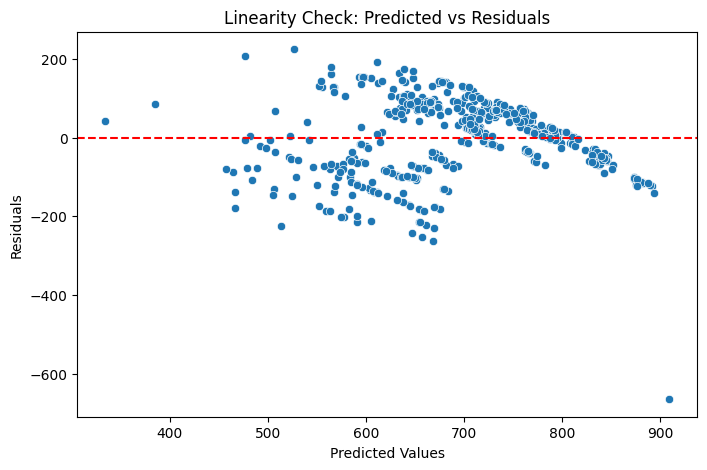


Durbin-Watson Statistic: 2.038883226365426

Breusch-Pagan Test: p-value = 0.32685882076901035


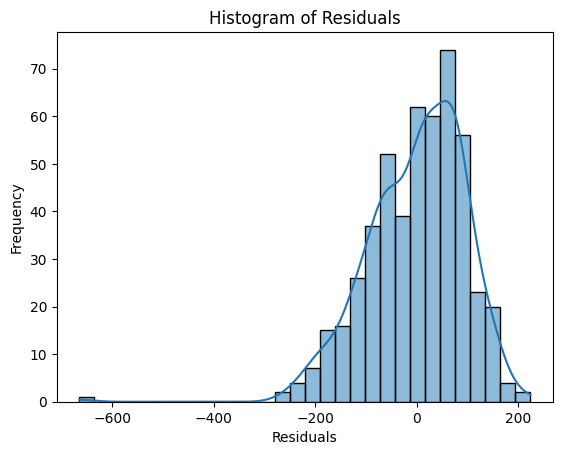

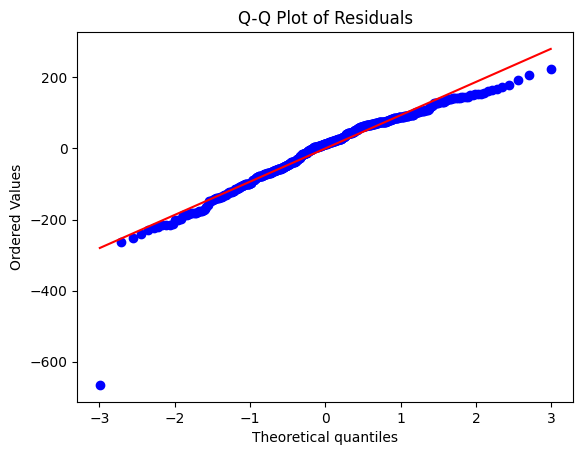


Performance Metrics:
       Random Forest          MLR
MAE        7.194483    68.816525
MSE      198.580254  7588.675394
MAPE       1.377316    11.376018


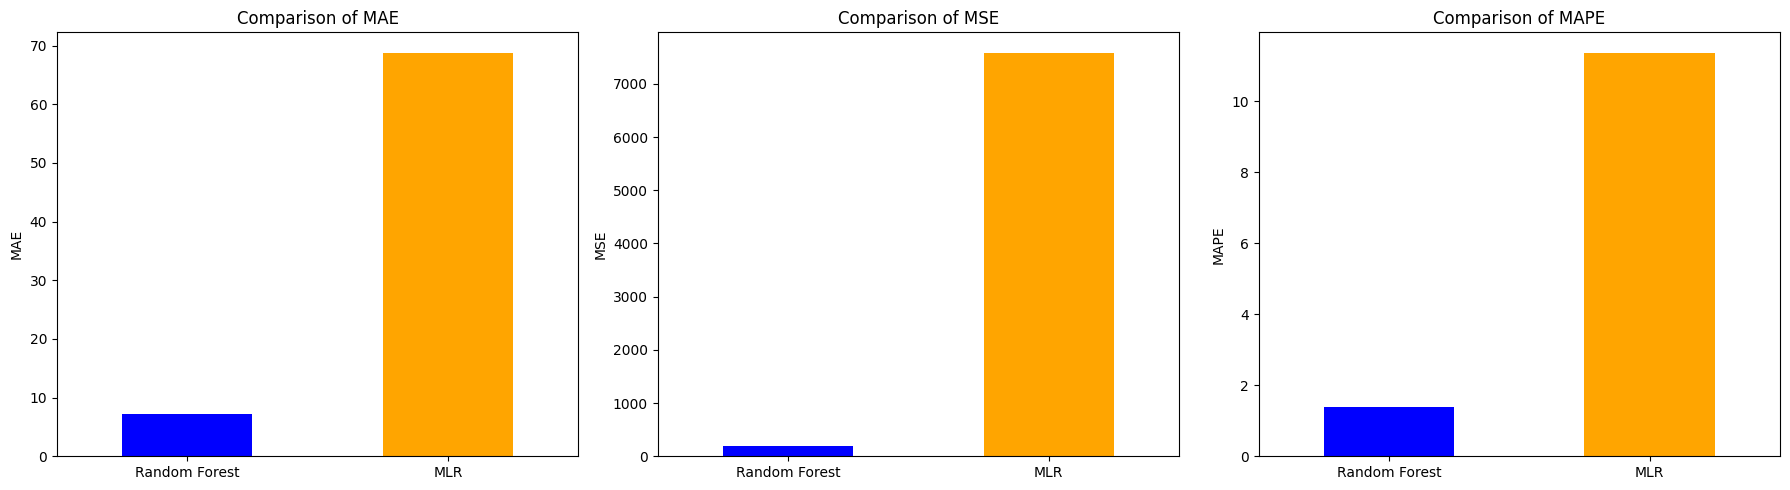

<ipython-input-9-85a4ce129568>:131: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importance_df["Importance"], y=importance_df["Feature"], palette="viridis")


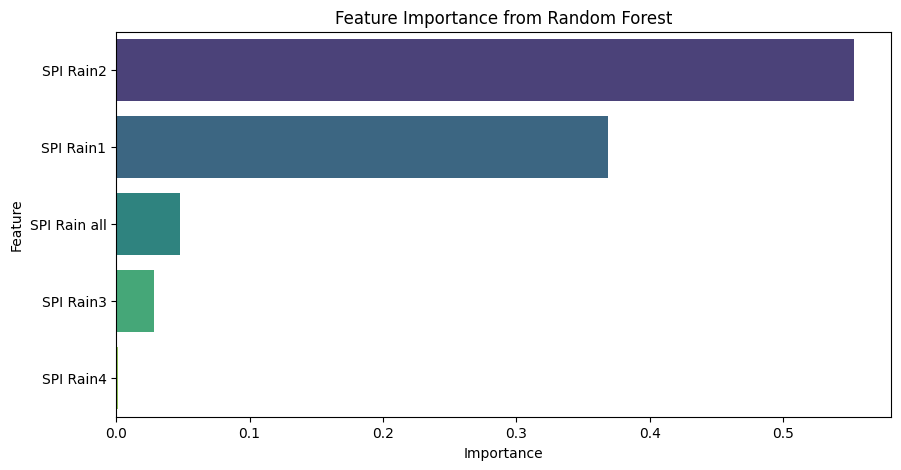

<ipython-input-9-85a4ce129568>:131: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importance_df["Importance"], y=importance_df["Feature"], palette="viridis")


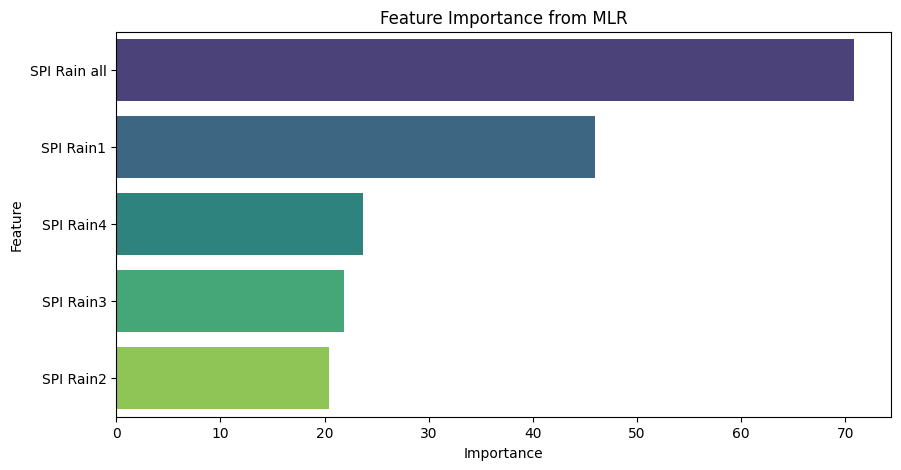

In [9]:
from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import het_breuschpagan
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# เชื่อมต่อ Google Drive
drive.mount('/content/drive')

# โหลดข้อมูล
file_path = "/content/drive/MyDrive/project 68/test625_model.xlsx"
df = pd.read_excel(file_path, sheet_name='Sheet1')

# แปลงข้อมูลเป็นตัวเลข (ลบคอลัมน์ข้อความที่ไม่จำเป็น)
df = df.drop(columns=['senario', 'stage1', 'stage2', 'stage3', 'stage4'])

# แยก features และ target
X = df.drop(columns=['simulated yield'])
y = df['simulated yield']

# แบ่งชุดข้อมูล train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ตรวจสอบ Multicollinearity (VIF)
vif_data = pd.DataFrame()
vif_data["Feature"] = X_train.columns
vif_data["VIF"] = [variance_inflation_factor(X_train.values, i) for i in range(X_train.shape[1])]
print("\nVariance Inflation Factor (VIF):\n", vif_data)

# กรองเฉพาะตัวแปรที่มี VIF < 10
selected_features = vif_data.loc[vif_data["VIF"] < 10, "Feature"].values
X_train_filtered = X_train[selected_features]
X_test_filtered = X_test[selected_features]

# Fit MLR เพื่อตรวจสอบสมมติฐาน
mlr = LinearRegression()
mlr.fit(X_train_filtered, y_train)
y_pred_mlr = mlr.predict(X_train_filtered)
residuals = y_train - y_pred_mlr

# ตรวจสอบ Linearity (Residual Plot)
plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_pred_mlr, y=residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Linearity Check: Predicted vs Residuals")
plt.show()

# ตรวจสอบ Independence (Durbin-Watson Test)
dw_value = durbin_watson(residuals)
print(f"\nDurbin-Watson Statistic: {dw_value}")

# ตรวจสอบ Homoscedasticity (Breusch-Pagan Test)
X_train_const = sm.add_constant(X_train_filtered)
bp_test = het_breuschpagan(residuals, X_train_const)
print(f"\nBreusch-Pagan Test: p-value = {bp_test[1]}")

# ตรวจสอบ Normality ของ Residuals (Histogram และ Q-Q Plot)
sns.histplot(residuals, kde=True, bins=30)
plt.title("Histogram of Residuals")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.show()

import scipy.stats as stats
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals")
plt.show()

# ฟังก์ชันคำนวณค่าความคลาดเคลื่อน
def evaluate_model(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
    return mae, mse, mape, y_pred, model

# สร้างและทดสอบโมเดลหลังการปรับปรุง
models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "MLR": LinearRegression()
}

results = {}
predictions = {}
feature_importances = {}

for name, model in models.items():
    mae, mse, mape, y_pred, trained_model = evaluate_model(model, X_train_filtered, X_test_filtered, y_train, y_test)
    results[name] = [mae, mse, mape]
    predictions[name] = y_pred

    # เก็บค่าความสำคัญของตัวแปรแยกสำหรับแต่ละโมเดล
    if hasattr(trained_model, 'feature_importances_'):
        feature_importances[name] = trained_model.feature_importances_
    elif hasattr(trained_model, 'coef_'):
        feature_importances[name] = np.abs(trained_model.coef_)

# แสดงผลลัพธ์
metrics = ["MAE", "MSE", "MAPE"]
results_df = pd.DataFrame(results, index=metrics)
print("\nPerformance Metrics:\n", results_df)

# แสดงกราฟค่าความคลาดเคลื่อน
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, metric in enumerate(metrics):
    results_df.loc[metric].plot(kind='bar', ax=axes[i], color=['blue', 'orange'])
    axes[i].set_title(f"Comparison of {metric}")
    axes[i].set_ylabel(metric)
    axes[i].set_xticklabels(results_df.columns, rotation=0)
plt.tight_layout()
plt.show()

# แสดงแผนภูมิตัวแปรที่มีผลมากที่สุด
for name, importances in feature_importances.items():
    feature_names = X_train_filtered.columns
    importance_df = pd.DataFrame({"Feature": feature_names, "Importance": importances})
    importance_df = importance_df.sort_values(by="Importance", ascending=False)

    plt.figure(figsize=(10, 5))
    sns.barplot(x=importance_df["Importance"], y=importance_df["Feature"], palette="viridis")
    plt.title(f"Feature Importance from {name}")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.show()
